In [2]:
scalar mu = 0.5
scalar sigma = 1


Running C:\Users\ndl1\websites\st-andrews-ec3301\profile.do ...



In [3]:
* Create empty dataset
set obs 200

* Fix a random seed
set seed 8471

* Generate random variable
gen x = rnormal(mu,sigma)

Number of observations (_N) was 200, now 200.


In [4]:
scalar list

     sigma =          1
        mu =         .5


In [5]:
sum x
scalar mean = r(mean)
gen x2 = (x-scalar(mean))^2
sum x2


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
           x |        200    .3895645    .9882484   -1.97056   3.007021

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
          x2 |        200    .9717517    1.344647   1.17e-08   6.851077


In [6]:
gen y = 1 + 0.5*x + rnormal()
quietly reg y x
ereturn list


scalars:
                  e(N) =  200
              e(sum_w) =  200
               e(df_m) =  1
               e(df_r) =  198
                  e(F) =  54.01552680014535
                 e(r2) =  .214334122528018
               e(rmse) =  .9929302113233063
                e(mss) =  53.25446987997427
                e(rss) =  195.2102601025921
               e(r2_a) =  .2103661130458363
                 e(ll) =  -281.3636934459951
               e(ll_0) =  -305.4860603665048
               e(rank) =  2

macros:
            e(cmdline) : "regress y x"
              e(title) : "Linear regression"
          e(marginsok) : "XB default"
                e(vce) : "ols"
             e(depvar) : "y"
                e(cmd) : "regress"
         e(properties) : "b V"
            e(predict) : "regres_p"
              e(model) : "ols"
          e(estat_cmd) : "regress_estat"

matrices:
                  e(b) :  1 x 2
                  e(V) :  2 x 2
               e(beta) :  1 x 1

functions:
       

In [7]:
mat list e(b)
mat list e(V)


e(b)[1,2]
            x      _cons
y1  .52346227  1.1454724

symmetric e(V)[2,2]
               x      _cons
    x  .00507285
_cons  -.0019762  .00569941


In [8]:
mat def beta = e(b)
mat def var = e(V)

In [9]:
dis beta[1,1]/sqrt(var[1,1])
reg y x

7.3495256

      Source |       SS           df       MS      Number of obs   =       200
-------------+----------------------------------   F(1, 198)       =     54.02
       Model |  53.2544699         1  53.2544699   Prob > F        =    0.0000
    Residual |   195.21026       198  .985910405   R-squared       =    0.2143
-------------+----------------------------------   Adj R-squared   =    0.2104
       Total |   248.46473       199  1.24856648   Root MSE        =    .99293



------------------------------------------------------------------------------


           y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]


-------------+----------------------------------------------------------------


           x |

   .5234623    .071224     7.35   0.000     .3830074    .6639172


       _cons |   1.145472   .0754944    15.17   0.000     .9965961    1.294349


------------------------------------------------------------------------------


In [10]:
local hi "Hello world!"
dis `local'


      Source |       SS           df       MS      Number of obs   =       200
-------------+----------------------------------   F(1, 198)       =     54.02
       Model |  53.2544699         1  53.2544699   Prob > F        =    0.0000
    Residual |   195.21026       198  .985910405   R-squared       =    0.2143
-------------+----------------------------------   Adj R-squared   =    0.2104
       Total |   248.46473       199  1.24856648   Root MSE        =    .99293

------------------------------------------------------------------------------
           y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           x |   .5234623    .071224     7.35   0.000     .3830074    .6639172
       _cons |   1.145472   .0754944    15.17   0.000     .9965961    1.294349
------------------------------------------------------------------------------


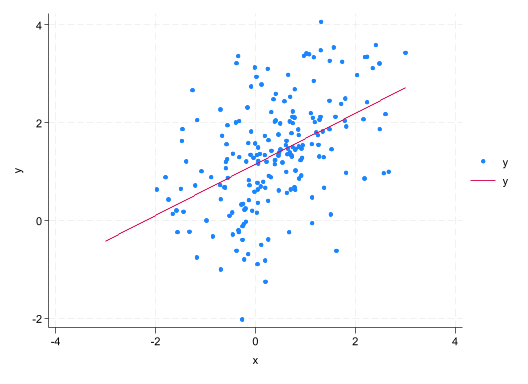

In [11]:
reg y x
local b0 = _b[_cons]
local b1 = _b[x]

twoway (scatter y x) (function y = `b0' + `b1'*x, range(-3 3))

In [12]:
global vars "y x"
dis $vars

-.75781232-1.1694912


In [13]:
macro list

vars:           y x
T_gm_fix_span:  0
S_E_depv:       y
S_E_cmd:        regress
S_level:        95
F1:             help advice;
F2:             describe;
F7:             save
F8:             use
S_ADO:          BASE;SITE;.;PERSONAL;PLUS;OLDPLACE
S_StataSE:      SE
S_CONSOLE:      console
S_OS:           Windows
S_OSDTL:        64-bit
S_MACH:         PC (64-bit x86-64)
_b1:            .5234622704964526
_b0:            1.145472410592256
_hi:            Hello world!
S_FN:           data/lcf_2023.dta
S_FNDATE:       15 Jul 2026 10:41


In [14]:
forvalues i = 0(5)20{
  dis `i'^2
}

0
25
100
225
400


In [15]:
forvalues num = 1/10{
  dis `num'*2
}

2
4
6
8
10
12
14
16
18
20


In [16]:
foreach var in y x {
  sum `var'
}


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
           y |        200    1.349395    1.117393  -2.026019   4.060859

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
           x |        200    .3895645    .9882484   -1.97056   3.007021


In [17]:
foreach var of global vars {
  sum `var'
}


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
           y |        200    1.349395    1.117393  -2.026019   4.060859

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
           x |        200    .3895645    .9882484   -1.97056   3.007021


In [18]:
* Create an arbitrary dummy variable =1 for the first 100 observations and =0 otherwise:
gen d = _n<=100

* Summarize y for each value of d

levelsof d
return list

0 1

scalars:
                  r(N) =  200
                  r(r) =  2

macros:
             r(levels) : "0 1"


In [19]:
local levels = r(levels)
foreach i of local levels {
  sum y if d==`i'
}


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
           y |        100    1.452805    1.215874  -2.026019   4.060859

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
           y |        100    1.245984    1.004883  -1.003003   3.539168
